In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ensure necessary folders exist
os.makedirs('data', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)

In [3]:
# Generate a realistic 365-day weather dataset
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')

In [4]:
# Simulate temperature and rainfall
temperature = 25 + 10 * np.sin(np.linspace(0, 2 * np.pi, 365)) + np.random.normal(0, 2, 365)
rainfall = np.where(temperature > 28, np.random.exponential(15, 365), np.random.exponential(3, 365))
humidity = np.clip(60 + rainfall * 1.5 + np.random.normal(0, 5, 365), 30, 98)

In [5]:
# Assign conditions
conditions = ['Heavy Rain' if r > 20 else 'Light Rain' if r > 5 else 'Cloudy' if r > 1 else 'Sunny' for r in rainfall]

In [6]:
# Create DataFrame and save as CSV
df_weather = pd.DataFrame({
    'Date': dates,
    'Temperature_C': np.round(temperature, 1),
    'Rainfall_mm': np.round(rainfall, 1),
    'Humidity_pct': np.round(humidity, 1),
    'Condition': conditions
})

df_weather.to_csv('data/weather_data.csv', index=False)
print("weather_data.csv successfully created in data/ folder!")

weather_data.csv successfully created in data/ folder!


In [7]:
# Display basic dataset information
print("\nDataset Shape:", df_weather.shape)
display(df_weather.head())


Dataset Shape: (365, 5)


,Date,Temperature_C,Rainfall_mm,Humidity_pct,Condition
0,2025-01-01,26.0,0.6,58.9,Sunny
1,2025-01-02,24.9,2.1,60.3,Cloudy
2,2025-01-03,26.6,1.6,64.3,Cloudy
3,2025-01-04,28.6,52.5,98.0,Heavy Rain
4,2025-01-05,25.2,1.4,61.7,Cloudy


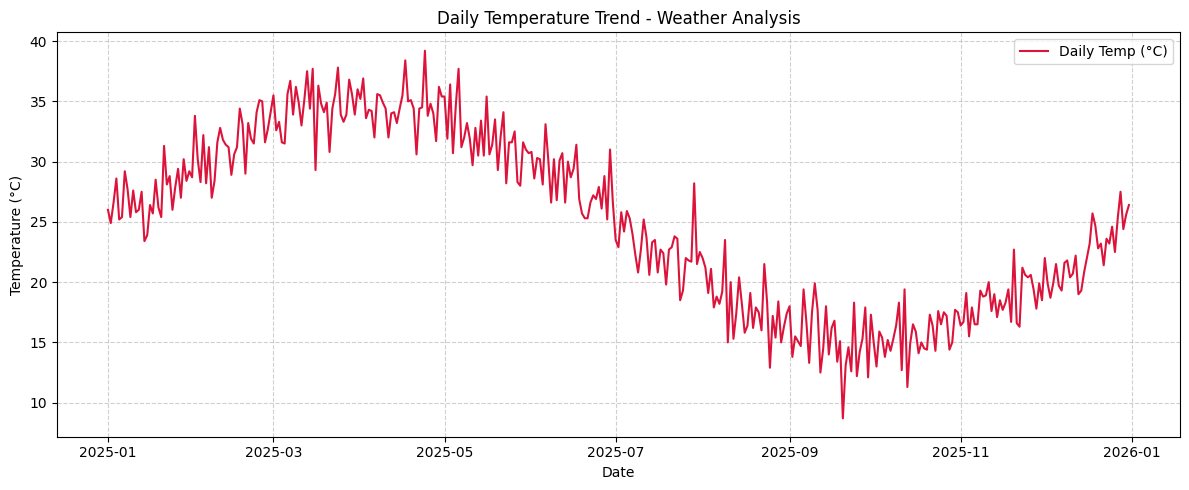

In [8]:
# 1. Temperature Trend Over Time
plt.figure(figsize=(12, 5))
plt.plot(df_weather['Date'], df_weather['Temperature_C'], color='crimson', linewidth=1.5, label='Daily Temp (°C)')
plt.title('Daily Temperature Trend - Weather Analysis')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

In [9]:
# Save visualization
plt.savefig('visualizations/project3_temp_trend.png')
plt.show()

<Figure size 640x480 with 0 Axes>

C:\Users\ajasl\AppData\Local\Temp\ipykernel_27948\258735115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


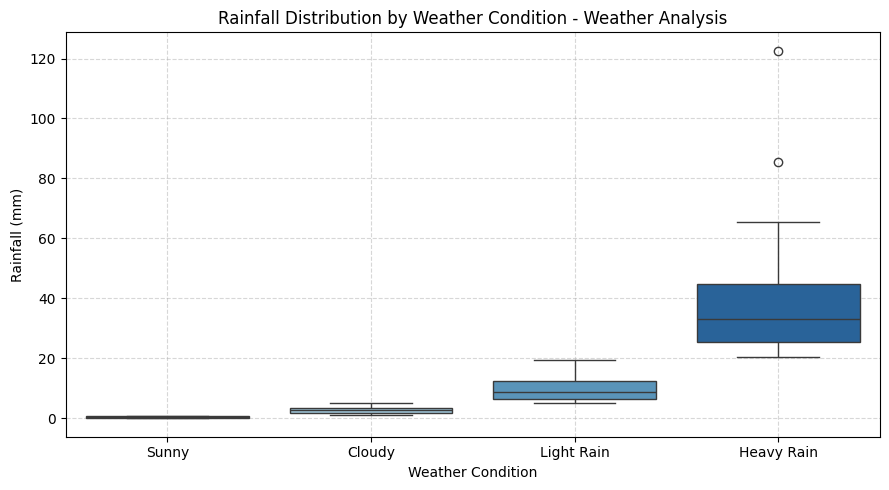

In [10]:
# 2. Rainfall Distribution by Weather Condition
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_weather,
    x='Condition',
    y='Rainfall_mm',
    order=['Sunny', 'Cloudy', 'Light Rain', 'Heavy Rain'],
    palette='Blues'
)
plt.title('Rainfall Distribution by Weather Condition - Weather Analysis')
plt.xlabel('Weather Condition')
plt.ylabel('Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

In [11]:
# Save visualization
plt.savefig('visualizations/project3_rainfall_distribution.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [12]:
# Extract month name for seasonal grouping
df_weather['Month'] = df_weather['Date'].dt.strftime('%b')

In [13]:
# Order months chronologically
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_humidity = df_weather.groupby('Month')['Humidity_pct'].mean().reindex(months_order)

C:\Users\ajasl\AppData\Local\Temp\ipykernel_27948\464377805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_humidity.index, y=monthly_humidity.values, palette='cool')


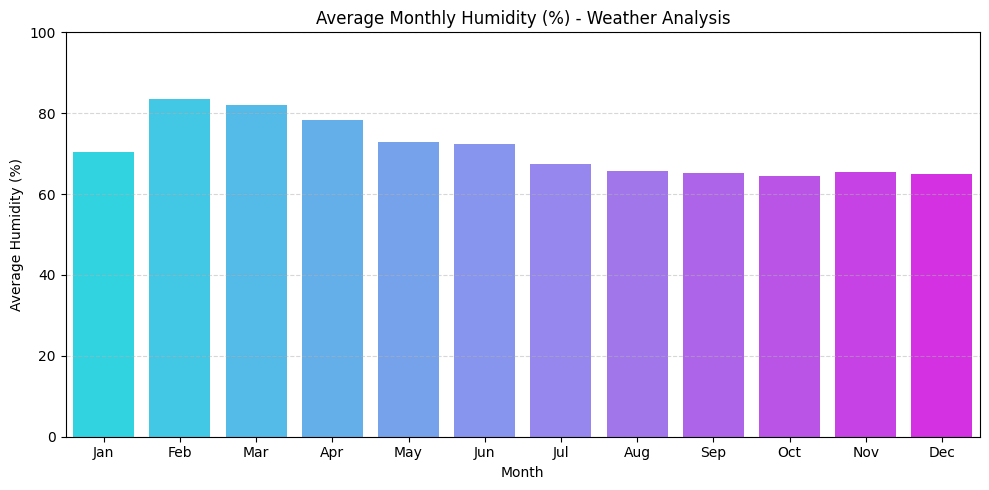

In [14]:
# 3. Monthly Average Humidity Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_humidity.index, y=monthly_humidity.values, palette='cool')
plt.title('Average Monthly Humidity (%) - Weather Analysis')
plt.xlabel('Month')
plt.ylabel('Average Humidity (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

In [15]:
# Save visualization
plt.savefig('visualizations/project3_monthly_humidity.png')
plt.show()

<Figure size 640x480 with 0 Axes>